<a href="https://colab.research.google.com/github/riyarani6180/Simple-Linear-Regression/blob/main/simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/Height_Weight.csv')

In [ ]:
df.head()

,Height,Weight
0,150,50
1,152,52
2,155,54
3,158,57
4,160,59


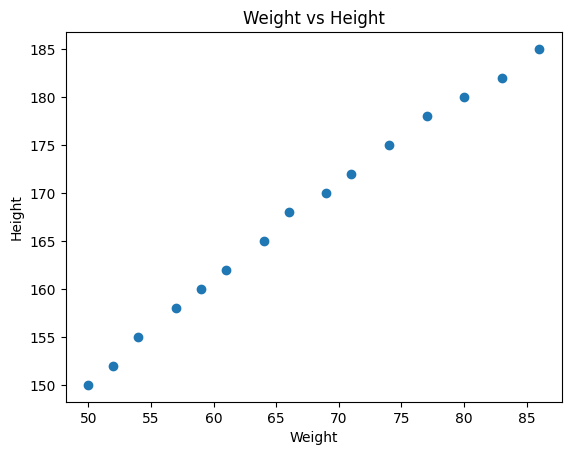

In [ ]:
##scatter plot:--help ypu to projet your data points
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')
plt.show()

In [ ]:
## correlation
df.corr()

,Height,Weight
Height,1.000000,0.997688
Weight,0.997688,1.000000


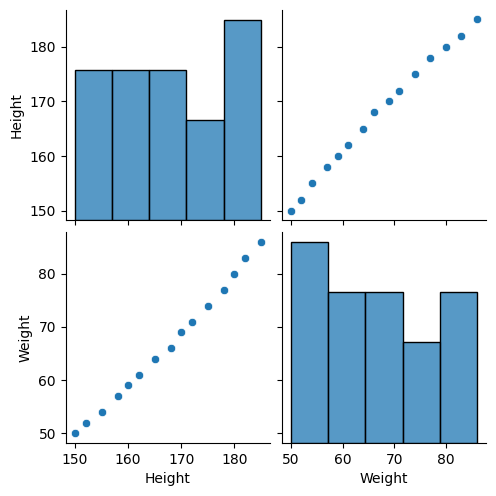

In [ ]:

## seaborn for visualization
import seaborn as sns
sns.pairplot(df)


In [ ]:
## Independent and dependent features
X=df[['Weight']] ## independent features should be data frame or 2 dimensional array
y=df['Height'] ## this variable can  be in series form or 1 d array bcz this is dependent features

In [ ]:
X_series=df['Weight']
np.array(X_series).shape

(15,)

In [ ]:
## Train Test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
np.array(y).shape

(15,)

In [ ]:
X_train.shape

(12, 1)

In [ ]:
## standardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
X_test

array([[-1.40285364],
       [-0.36156022],
       [ 0.07231204]])

In [ ]:
X_train

array([[ 0.24586095],
       [ 1.54747772],
       [-0.79543247],
       [-1.22930473],
       [ 1.28715437],
       [ 0.5061843 ],
       [-0.18801131],
       [ 0.76650766],
       [-0.96898138],
       [-1.57640254],
       [-0.62188357],
       [ 1.02683101]])

In [ ]:

###  Simple Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
print("coeffient or slope: ",lr.coef_)


coeffient or slope:  [11.08182061]


In [ ]:
print("intercept: ", lr.intercept_)

intercept:  168.75


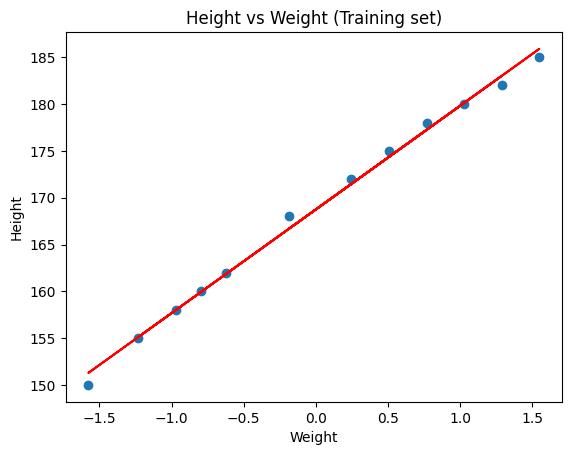

In [ ]:
## plot Traning data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,lr.predict(X_train),color='red')
plt.title('Height vs Weight (Training set)')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [ ]:
## prediction for test data
## predicted height output = intercept +coef_(Weights)
## y_pred_test =  168.75 +11.08(X_test)
y_pred=lr.predict(X_test)

In [ ]:
### performance matrices
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error
print("MAE: ",mean_absolute_error(y_test,y_pred))
print("MSE: ",mean_squared_error(y_test,y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))

MAE:  0.6364080039043453
MSE:  0.5721356263287596
RMSE:  0.756396474296886


In [ ]:
### R square
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9900594196197706

In [ ]:
## Adjusted R square
1-(1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.9801188392395412

In [ ]:
### OLS linear regression
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
lr_1 = sm.OLS(y_train, X_train_sm).fit()

In [ ]:
pr = lr_1.predict(X_train_sm)
print(pr)

[171.47458691 185.89887053 159.93516001 155.12706547 183.0140138
 174.35944363 166.66649237 177.24430036 158.01192219 151.28058983
 161.85839782 180.12915708]


In [ ]:
print(lr_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Height   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     2243.
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           4.24e-13
Time:                        11:39:09   Log-Likelihood:                -13.412
No. Observations:                  12   AIC:                             30.82
Df Residuals:                      10   BIC:                             31.79
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        168.7500      0.234    721.247      0.0

In [ ]:
## prediction for new data
lr.predict(sc.transform([[72]]))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([172.43620581])